In [ ]:
from pathlib import Path
import pandas as pd

candidates = [Path.cwd(), Path.cwd() / "DATA", Path.cwd().parent / "DATA"]
for candidate in candidates:
    communes_path = candidate / "communes_idf_clean.csv"
    logement_path = candidate / "logement_idf_clean.csv"
    if communes_path.exists() and logement_path.exists():
        communes = pd.read_csv(communes_path)
        logement = pd.read_csv(logement_path)
        print(f"CSV charges depuis: {candidate}")
        break
else:
    raise FileNotFoundError("Impossible de trouver communes_idf_clean.csv et logement_idf_clean.csv")

/tmp/ipykernel_17963/1009486345.py:3: DtypeWarning: Columns (1,12,14,16,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  communes = pd.read_csv("/communes-france-2025.csv")


In [ ]:
logement.head()


,IRIS,COM,TYP_IRIS,LAB_IRIS,P22_LOG,P22_RP,P22_RSECOCC,P22_LOGVAC,P22_MAISON,P22_APPART,...,P22_RP_HABFOR,P22_RP_CASE,P22_RP_MIBOIS,P22_RP_MIDUR,C22_RP_NORME,C22_RP_SOUSOCC_MOD,C22_RP_SOUSOCC_ACC,C22_RP_SOUSOCC_TACC,C22_RP_SUROCC_MOD,C22_RP_SUROCC_ACC
0,010010000,01001,Z,5,379.000000,354.000000,11.000000,14.000000,369.000000,9.000000,...,NaN,NaN,NaN,NaN,9.817143,68.720000,137.440000,137.440000,0.000000,0.000000
1,010020000,01002,Z,5,175.000000,121.000000,41.000000,13.000000,173.000000,2.000000,...,NaN,NaN,NaN,NaN,4.963636,9.927273,39.709091,64.527273,0.000000,0.000000
2,010040101,01004,H,1,935.984809,835.047694,36.017461,64.919654,408.628548,489.281402,...,NaN,NaN,NaN,NaN,101.267599,223.425915,212.373383,130.053461,35.667175,0.000000
3,010040102,01004,H,1,2143.965482,1897.387812,34.073609,212.504061,584.723661,1541.653378,...,NaN,NaN,NaN,NaN,479.038543,521.426326,253.641193,312.742736,198.997643,11.478312
4,010040201,01004,H,1,2466.460128,2191.740808,22.976112,251.743208,842.848349,1607.044377,...,NaN,NaN,NaN,NaN,671.868935,760.918656,488.073993,351.917278,96.663417,9.895051


In [ ]:
communes.head()

,Unnamed: 0,code_insee,nom_standard,nom_sans_pronom,nom_a,nom_de,nom_sans_accent,nom_standard_majuscule,typecom,typecom_texte,...,longitude_mairie,latitude_centre,longitude_centre,grille_densite,grille_densite_texte,niveau_equipements_services,niveau_equipements_services_texte,gentile,url_wikipedia,url_villedereve
0,0,01001,L'Abergement-Clémenciat,Abergement-Clémenciat,à Abergement-Clémenciat,de l'Abergement-Clémenciat,l-abergement-clemenciat,L'ABERGEMENT-CLÉMENCIAT,COM,commune,...,4.921,46.153,4.926,6,Rural à habitat dispersé,0.0,communes non pôle,NaN,https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01001-l-abergemen...
1,1,01002,L'Abergement-de-Varey,Abergement-de-Varey,à Abergement-de-Varey,de l'Abergement-de-Varey,l-abergement-de-varey,L'ABERGEMENT-DE-VAREY,COM,commune,...,5.423,46.009,5.428,6,Rural à habitat dispersé,0.0,communes non pôle,"Abergementais, Abergementaises",https://fr.wikipedia.org/wiki/fr:L'Abergement-...,https://villedereve.fr/ville/01002-l-abergemen...
2,2,01004,Ambérieu-en-Bugey,Ambérieu-en-Bugey,à Ambérieu-en-Bugey,d'Ambérieu-en-Bugey,amberieu-en-bugey,AMBÉRIEU-EN-BUGEY,COM,commune,...,5.360,45.961,5.373,2,Centres urbains intermédiaires,3.0,centres structurants d'équipements et de services,"Ambarrois, Ambarroises",https://fr.wikipedia.org/wiki/fr:Ambérieu-en-B...,https://villedereve.fr/ville/01004-amberieu-en...
3,3,01005,Ambérieux-en-Dombes,Ambérieux-en-Dombes,à Ambérieux-en-Dombes,d'Ambérieux-en-Dombes,amberieux-en-dombes,AMBÉRIEUX-EN-DOMBES,COM,commune,...,4.903,45.996,4.912,5,Bourgs ruraux,1.0,centres locaux d'équipements et de services,Ambarrois,https://fr.wikipedia.org/wiki/fr:Ambérieux-en-...,https://villedereve.fr/ville/01005-amberieux-e...
4,4,01006,Ambléon,Ambléon,à Ambléon,d'Ambléon,ambleon,AMBLÉON,COM,commune,...,5.601,45.750,5.594,6,Rural à habitat dispersé,0.0,communes non pôle,Ambléonais,https://fr.wikipedia.org/wiki/fr:Ambléon,https://villedereve.fr/ville/01006-ambleon


In [ ]:
def clean(df):
    df.columns = df.columns.str.lower().str.strip()
    return df

communes = clean(communes)
logement = clean(logement)

In [ ]:
print(communes.columns)
print(logement.columns)

Index(['unnamed: 0', 'code_insee', 'nom_standard', 'nom_sans_pronom', 'nom_a',
       'nom_de', 'nom_sans_accent', 'nom_standard_majuscule', 'typecom',
       'typecom_texte', 'reg_code', 'reg_nom', 'dep_code', 'dep_nom',
       'canton_code', 'canton_nom', 'epci_code', 'epci_nom', 'academie_code',
       'academie_nom', 'code_postal', 'codes_postaux', 'zone_emploi',
       'code_insee_centre_zone_emploi', 'code_unite_urbaine',
       'nom_unite_urbaine', 'taille_unite_urbaine',
       'type_commune_unite_urbaine', 'statut_commune_unite_urbaine',
       'population', 'superficie_hectare', 'superficie_km2', 'densite',
       'altitude_moyenne', 'altitude_minimale', 'altitude_maximale',
       'latitude_mairie', 'longitude_mairie', 'latitude_centre',
       'longitude_centre', 'grille_densite', 'grille_densite_texte',
       'niveau_equipements_services', 'niveau_equipements_services_texte',
       'gentile', 'url_wikipedia', 'url_villedereve'],
      dtype='object')
Index(['iris', 'com'

In [ ]:
communes = communes.rename(columns={
    "code_insee": "code_commune"
})

logement = logement.rename(columns={
    "com": "code_commune"
})

communes["code_commune"] = communes["code_commune"].astype(str)
logement["code_commune"] = logement["code_commune"].astype(str)

In [ ]:
idf = ["75","77","78","91","92","93","94","95"]

communes = communes[communes["code_commune"].str[:2].isin(idf)]
logement = logement[logement["code_commune"].str[:2].isin(idf)]

print(communes.shape)
print(logement.shape)

(1267, 47)
(5264, 101)


In [ ]:
communes = communes[[
    "code_commune",
    "nom_standard",
    "population",
    "latitude_centre",
    "longitude_centre"
]].copy()

In [ ]:
logement.columns

Index(['iris', 'code_commune', 'typ_iris', 'lab_iris', 'p22_log', 'p22_rp',
       'p22_rsecocc', 'p22_logvac', 'p22_maison', 'p22_appart',
       ...
       'p22_rp_habfor', 'p22_rp_case', 'p22_rp_mibois', 'p22_rp_midur',
       'c22_rp_norme', 'c22_rp_sousocc_mod', 'c22_rp_sousocc_acc',
       'c22_rp_sousocc_tacc', 'c22_rp_surocc_mod', 'c22_rp_surocc_acc'],
      dtype='object', length=101)

In [ ]:
logement = logement[[
    "code_commune",
    "p22_log",
    "p22_rp"
]]

In [ ]:
logement = logement.dropna()
communes = communes.dropna()

In [ ]:
df = communes.merge(logement, on="code_commune", how="left")

In [ ]:
df["logements"] = df["p22_log"]
df["residences"] = df["p22_rp"]

df["ratio_collectif"] = df["residences"] / df["logements"]

In [ ]:
df = df.fillna(0)
df = df.drop_duplicates()

fin du nettoyage


In [ ]:
df["densite"] = df["population"]

In [ ]:
df["ratio_collectif"] = df["residences"] / df["logements"]

In [ ]:
df["tension_parking"] = df["population"] / df["logements"]

In [ ]:
df["score"] = (
    df["densite"] * 0.4 +
    df["ratio_collectif"] * 0.3 +
    df["tension_parking"] * 0.3
)

In [ ]:
top = df.sort_values("score", ascending=False).head(15)

top[["nom_standard", "score"]]

,nom_standard,score
3818,Cergy,51458.378868
2056,Boulogne-Billancourt,47969.211231
2059,Boulogne-Billancourt,47959.935656
2057,Boulogne-Billancourt,47959.212296
2076,Boulogne-Billancourt,47958.217324
2077,Boulogne-Billancourt,47952.700837
2051,Boulogne-Billancourt,47952.163630
2041,Boulogne-Billancourt,47951.735910
2079,Boulogne-Billancourt,47951.566979
2078,Boulogne-Billancourt,47951.446186


In [ ]:
df["pression_urbaine"] = df["densite"] * df["ratio_collectif"]

In [ ]:
df["logement_par_habitant"] = df["logements"] / df["population"]

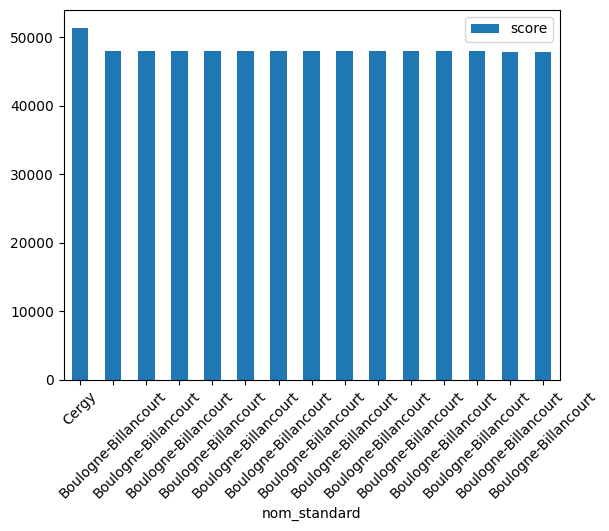

In [ ]:
import matplotlib.pyplot as plt

top.plot(x="nom_standard", y="score", kind="bar")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_grouped = df.groupby("nom_standard").agg({
    "score": "mean"
}).reset_index()

In [ ]:
top = df_grouped.sort_values("score", ascending=False).head(10)

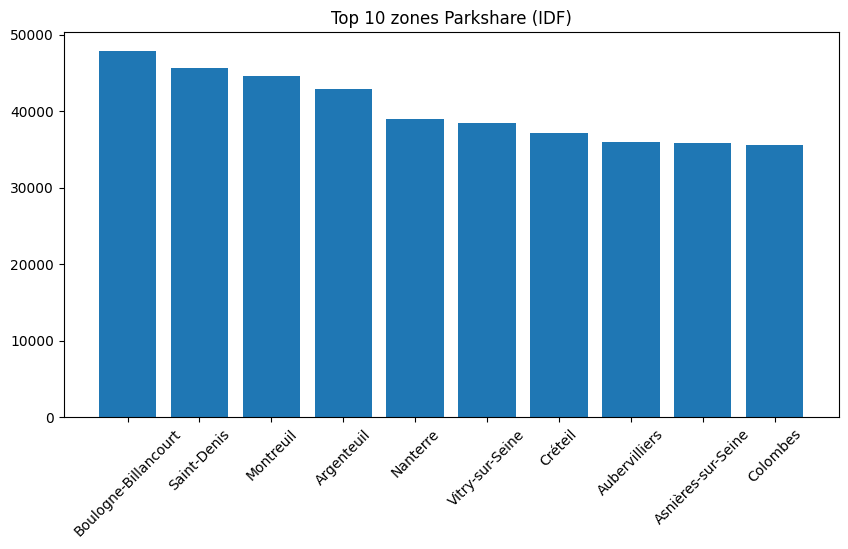

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(top["nom_standard"], top["score"])
plt.xticks(rotation=45)
plt.title("Top 10 zones Parkshare (IDF)")
plt.show()

Le graphique à barres intitulé "Top 10 zones Parkshare (IDF)" visualise efficacement les communes avec le score le plus élevé, calculé en fonction de la densité de population, du ratio de résidences collectives et de la tension de stationnement.

D'après le graphique, il est clair que Boulogne-Billancourt se distingue avec le score le plus élevé, indiquant un potentiel ou un besoin très important pour une solution 'Parkshare' basée sur vos critères définis. Saint-Denis et Montreuil suivent de près, affichant également des scores significatifs.

Cette visualisation aide à identifier rapidement les communes où les initiatives 'Parkshare' pourraient être les plus efficaces ou nécessaires dans la région Île-de-France, en se basant sur les facteurs combinés de votre modèle de notation.


In [ ]:
df["score"].describe()

,score
count,4260.000000
mean,13696.247577
std,12236.995049
min,10.972149
25%,3366.479470
50%,11056.790890
75%,21078.851558
max,51458.378868


Voici ce que chaque statistique signifie dans le contexte des scores calculés pour les zones Parkshare :

count (4260.000000) : Il y a 4260 entrées uniques (communes ou iris) pour lesquelles un score a été calculé. Cela indique la taille de votre échantillon.

mean (13696.247577) : La valeur moyenne du score est d'environ 13696. C'est la somme de tous les scores divisée par le nombre total de scores. C'est une mesure de la tendance centrale.

std (12236.995049) : L'écart-type est d'environ 12237. Il mesure la dispersion ou la variabilité des scores autour de la moyenne. Un écart-type élevé, comme celui-ci, indique que les scores sont très dispersés et qu'il y a une grande différence entre les zones en termes de besoin/potentiel pour Parkshare.

min (10.972149) : Le score minimum est d'environ 11. Cela représente la zone avec la plus faible combinaison de densité, ratio collectif et tension de parking dans votre jeu de données.

25% (3366.479470) : C'est le premier quartile. Cela signifie que 25% des zones ont un score inférieur ou égal à environ 3366.

50% (11056.790890) : C'est la médiane. Cela signifie que 50% des zones ont un score inférieur ou égal à environ 11057. Si la médiane est inférieure à la moyenne (ce qui est le cas ici), cela peut indiquer une distribution asymétrique vers la droite, où quelques scores très élevés tirent la moyenne vers le haut.

75% (21078.851558) : C'est le troisième quartile. Cela signifie que 75% des zones ont un score inférieur ou égal à environ 21079.

max (51458.378868) : Le score maximum est d'environ 51458. C'est le score le plus élevé trouvé dans votre ensemble de données, indiquant la zone avec le plus grand besoin/potentiel pour une solution Parkshare selon vos critères.

En résumé, ces statistiques révèlent que les scores sont très variés dans la région Île-de-France, avec une grande concentration de scores plus faibles et quelques zones exceptionnelles présentant un besoin très élevé.

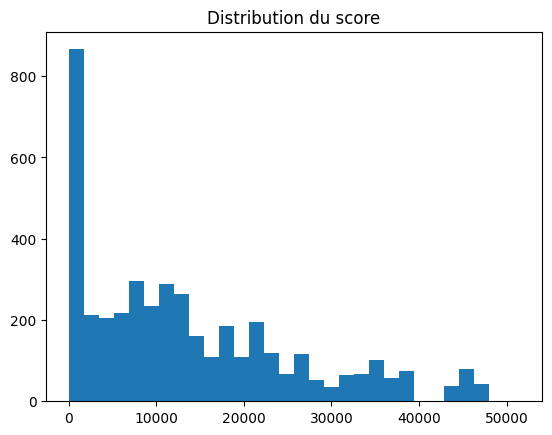

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["score"], bins=30)
plt.title("Distribution du score")
plt.show()

Le dernier graphique est un histogramme de la distribution du score. Il montre combien de communes se situent dans différentes plages de scores.

Voici comment l'interpréter :

L'axe horizontal (X) représente les différentes valeurs du score.
L'axe vertical (Y) représente le nombre de communes (ou la fréquence) qui ont un score dans cette plage spécifique.
Interprétation du graphique :

Vous remarquerez probablement que la distribution est fortement asymétrique vers la droite (skewed right). Cela signifie que :

La majorité des communes ont des scores faibles : Une grande partie des barres de l'histogramme sont concentrées vers la gauche, indiquant que la plupart des communes ont des scores relativement bas. Cela suggère que la plupart des zones n'ont pas une très forte tension en termes de besoins 'Parkshare' selon vos critères.
Quelques communes ont des scores très élevés : La queue de l'histogramme s'étend loin vers la droite, montrant qu'il y a un petit nombre de communes avec des scores exceptionnellement élevés. Ces valeurs extrêmes correspondent aux communes que vous avez identifiées comme ayant le plus grand potentiel ou besoin pour 'Parkshare' (comme Boulogne-Billancourt, Saint-Denis, Montreuil).
En résumé, cet histogramme visualise la même information que les statistiques descriptives : il confirme une grande variabilité dans les scores et met en évidence la présence de quelques "outliers" avec des besoins très importants, tandis que la majorité des zones ont des besoins plus modérés.



In [ ]:
corr = df[[
    "population",
    "logements",
    "ratio_collectif",
    "tension_parking",
    "score"
]].corr()

corr

,population,logements,ratio_collectif,tension_parking,score
population,1.000000,0.281200,0.138752,0.032786,0.999354
logements,0.281200,1.000000,0.065835,-0.066988,0.279981
ratio_collectif,0.138752,0.065835,1.000000,-0.042834,0.136960
tension_parking,0.032786,-0.066988,-0.042834,1.000000,0.068678
score,0.999354,0.279981,0.136960,0.068678,1.000000


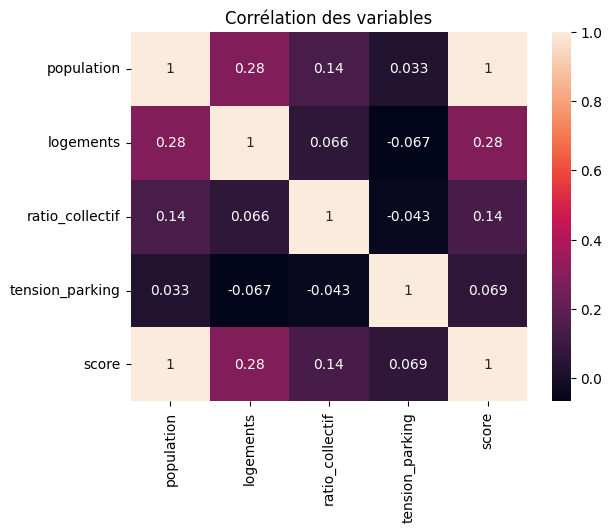

In [ ]:
import seaborn as sns

sns.heatmap(corr, annot=True)
plt.title("Corrélation des variables")
plt.show()

Interprétation des corrélations principales :

score et population (0.999354) : Il y a une corrélation extrêmement forte et positive entre le score et la population. Cela signifie que plus une commune est peuplée, plus son score est élevé. C'est le lien le plus fort sur la carte, ce qui est logique étant donné que la population est un composant majeur de la densite et, par conséquent, du score (avec un poids de 0.4).

score et logements (0.279981) : Il y a une corrélation positive modérée entre le score et le nombre de logements. Plus il y a de logements, plus le score a tendance à être élevé.

score et ratio_collectif (0.136960) : La corrélation est faiblement positive entre le score et le ratio de logements collectifs. Cela suggère que si un plus grand nombre de logements sont collectifs, cela a un léger impact positif sur le score, mais moins que la population ou le nombre total de logements.

score et tension_parking (0.068678) : La corrélation est très faible et positive entre le score et la tension de parking. Cela indique que, bien que la tension_parking contribue au score, son influence directe est moins prononcée que celle des autres facteurs dans cette modélisation.

En résumé :

La heatmap confirme visuellement que le score est très fortement lié à la population. Les autres variables (logements, ratio_collectif, tension_parking) ont des corrélations positives avec le score, mais sont beaucoup moins prononcées. Cela met en évidence la prédominance de la population dans la détermination du score final, tel que défini par votre formule.

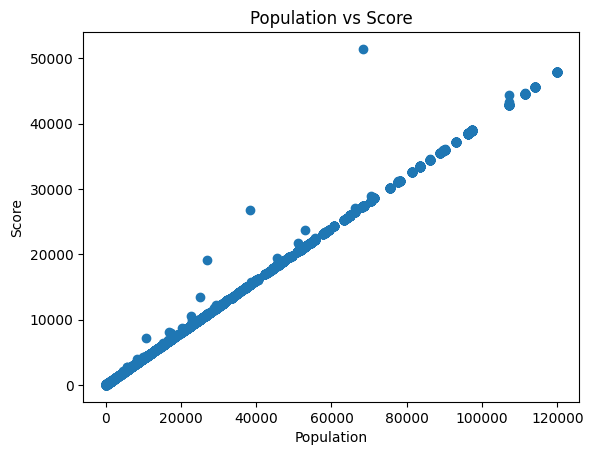

In [ ]:
plt.scatter(df["population"], df["score"])
plt.xlabel("Population")
plt.ylabel("Score")
plt.title("Population vs Score")
plt.show()

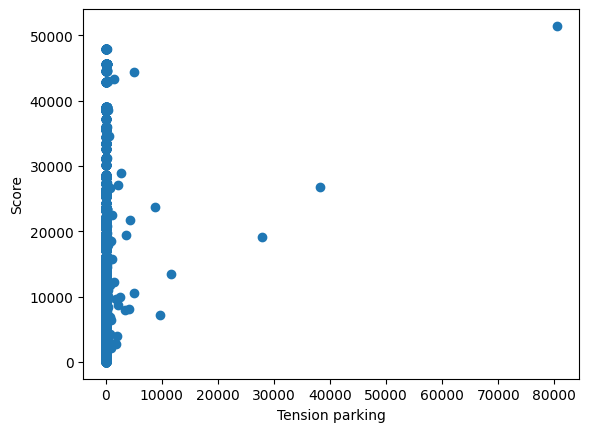

In [ ]:
plt.scatter(df["tension_parking"], df["score"])
plt.xlabel("Tension parking")
plt.ylabel("Score")
plt.show()

Interprétation du graphique :

En observant le nuage de points, vous devriez remarquer que :

Absence de forte corrélation linéaire visible : Contrairement au graphique population vs score où les points s'alignaient clairement le long d'une ligne, ici, les points semblent beaucoup plus dispersés. Il n'y a pas de tendance claire et forte indiquant que plus la tension_parking augmente, plus le score augmente de manière linéaire et prévisible.
Concentration des points à faible tension_parking : La majorité des points sont probablement regroupés vers les faibles valeurs de tension_parking, avec une dispersion plus large des scores dans cette zone.
Quelques points avec une tension_parking plus élevée : Il peut y avoir quelques points isolés ou des groupes de points avec des valeurs de tension_parking plus élevées, mais sans former une relation nette avec le score global.
En résumé :

Ce graphique confirme visuellement ce que la carte de chaleur des corrélations a montré : la variable tension_parking a une corrélation très faible avec le score total (0.068678). Cela signifie que, bien que la tension_parking soit incluse dans le calcul du score, elle n'est pas le facteur dominant qui explique les variations du score global. Les communes avec une tension de parking élevée n'ont pas nécessairement un score global très élevé, et vice versa, du moins pas de manière aussi prononcée que la population.

In [ ]:
df["indice_urbain"] = df["population"] * df["ratio_collectif"]

In [ ]:
df["departement"] = df["code_commune"].str[:2]

df.groupby("departement")["score"].mean()

,score
departement,
77,4158.739956
78,8556.040897
91,8385.445176
92,24308.467288
93,23041.854418
94,18994.695840
95,10762.545056


In [ ]:
from pathlib import Path

output_dir = Path.cwd() if Path.cwd().name == "DATA" else Path.cwd() / "DATA"
output_dir.mkdir(parents=True, exist_ok=True)

# Sauvegarder le DataFrame 'df' dans un fichier CSV
df.to_csv(output_dir / "donnees_clean_idf.csv", index=False)
print(f"Le fichier 'donnees_clean_idf.csv' a ete cree avec succes dans: {output_dir}")

Si vous souhaitez également sauvegarder les DataFrames `communes` et `logement` après nettoyage et filtrage pour l'IDF, vous pouvez faire de même :

In [ ]:
from pathlib import Path

output_dir = Path.cwd() if Path.cwd().name == "DATA" else Path.cwd() / "DATA"
output_dir.mkdir(parents=True, exist_ok=True)

communes.to_csv(output_dir / "communes_idf_clean.csv", index=False)
logement.to_csv(output_dir / "logement_idf_clean.csv", index=False)
print(f"Les fichiers communes_idf_clean.csv et logement_idf_clean.csv ont ete crees dans: {output_dir}")

Les fichiers 'communes_idf_clean.csv' et 'logement_idf_clean.csv' ont été créés avec succès.


*   `"donnees_clean_idf.csv"` est le nom du fichier que vous souhaitez créer.
*   `index=False` est important pour éviter d'écrire l'index du DataFrame comme une colonne dans votre fichier CSV.